In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("/content/survey.csv")

print("First 5 Rows:")
df.head()

First 5 Rows:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   objec

In [4]:
# Fill missing values
df = df.fillna(method='ffill')

print("Missing values handled")

Missing values handled


/tmp/ipykernel_507/3859885903.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Categorical data converted")

Categorical data converted


In [6]:
#target variable
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [7]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Update X_train and X_test to be scaled versions for model training
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000), # Increased max_iter
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results.append((name, acc))

    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 5.95%
Random Forest Accuracy: 22.62%
Decision Tree Accuracy: 80.95%
KNN Accuracy: 1.19%


##Data Visuals

###Bar Graph

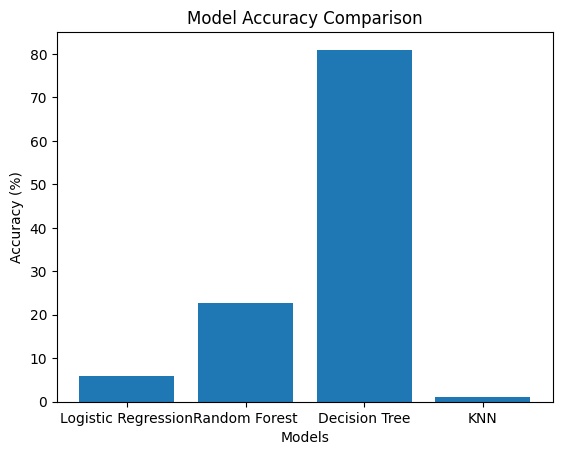

In [9]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()

###Histogram

<Figure size 1400x1000 with 0 Axes>

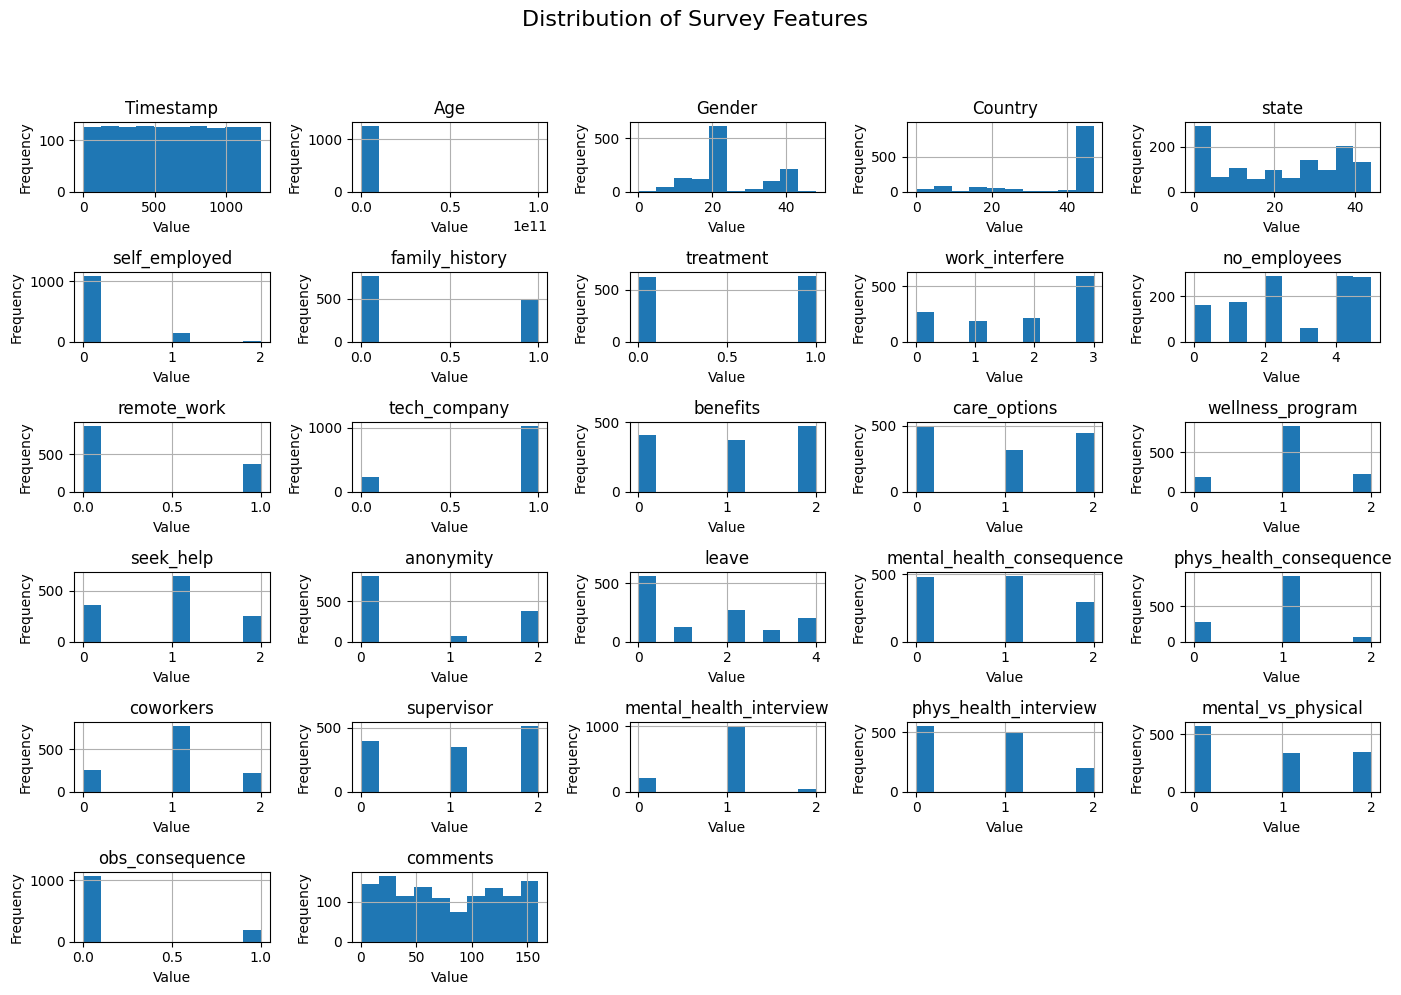

In [10]:
plt.figure(figsize=(14,10))
hist_plots = df.hist(figsize=(14,10))
plt.suptitle("Distribution of Survey Features", y=1.02, fontsize=16) # Adjust suptitle position

# Add axis labels to each subplot
for row_plots in hist_plots:
    for ax in row_plots:
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap with suptitle
plt.show()

###Accuracy Comparison Graph (Models)

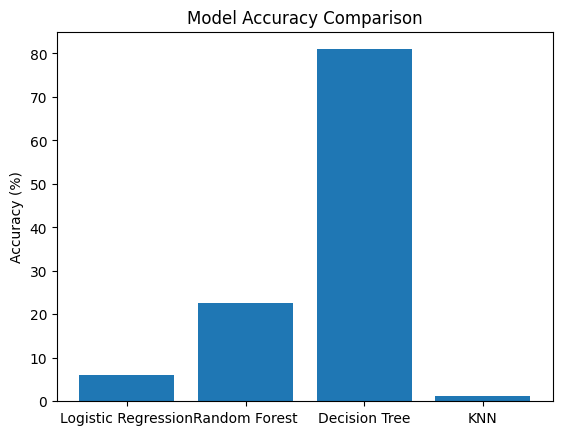

In [11]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

This Shows that the Decision Tree works better for our project

###Confusion Matrix

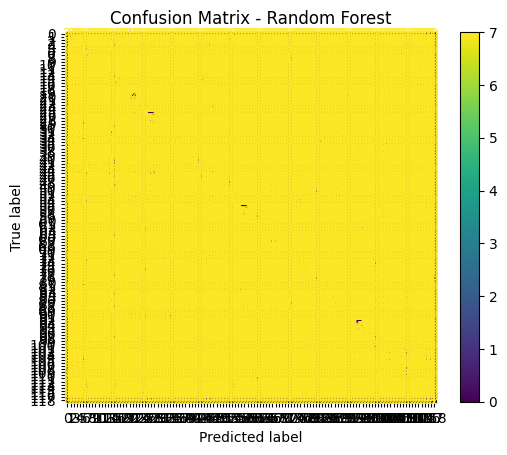

In [12]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [13]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# Get importance of each feature
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                      Feature  Importance
0                   Timestamp    0.185266
4                       state    0.082110
2                      Gender    0.050282
9                no_employees    0.050106
17                      leave    0.040661
3                     Country    0.040439
8              work_interfere    0.038303
1                         Age    0.037798
24         mental_vs_physical    0.035048
21                 supervisor    0.034495
23      phys_health_interview    0.034362
18  mental_health_consequence    0.033727
15                  seek_help    0.032890
20                  coworkers    0.032375
13               care_options    0.031731
12                   benefits    0.030665
14           wellness_program    0.026708
16                  anonymity    0.024435
6              family_history    0.022763
7                   treatment    0.022570
19    phys_health_consequence    0.021908
22    mental_health_interview    0.020182
10                remote_work    0

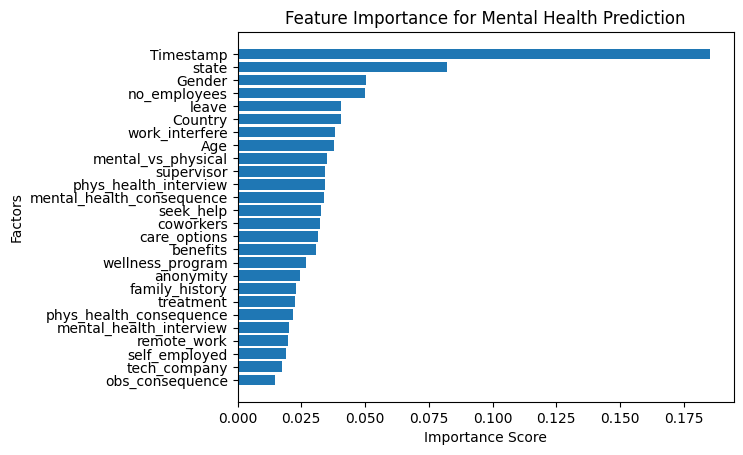

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance for Mental Health Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Factors")
plt.gca().invert_yaxis()
plt.show()

##Correlation Matrix

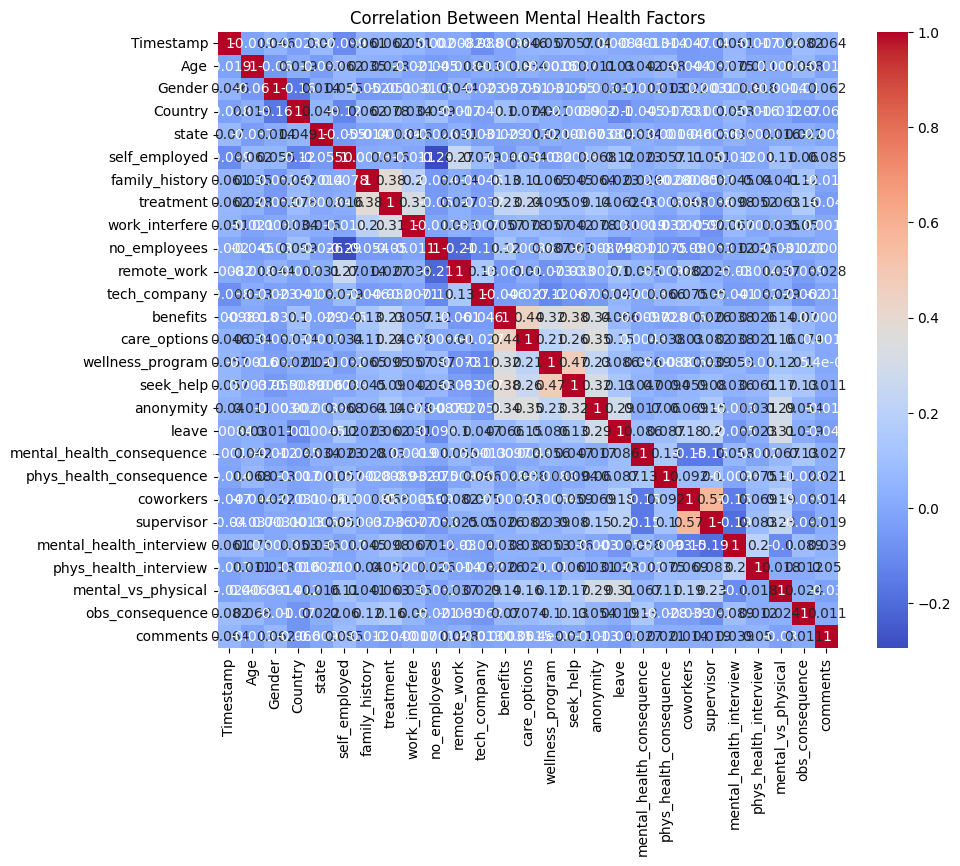

In [16]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Mental Health Factors")
plt.show()

In [17]:
def mental_state(score):
    if score == 0:
        return "😊 Happy"
    elif score == 1:
        return "😐 Sad"
    elif score == 2:
        return "😟 Stressed"
    else:
        return "😞 Depressed"

In [18]:
#Example

new_person = X_test.iloc[0:1]

prediction = best_model.predict(new_person)[0]

print("Predicted Mental Health State:", mental_state(prediction))

Predicted Mental Health State: 😞 Depressed
